**Import** **Libraries**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import FastICA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import hdbscan

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences

**Load Dataset (CSV)**

In [26]:
# Upload your CSV file in Colab
df = pd.read_csv("HDFS_100k.log_structured.csv")

# Use 'Content' column as logs
logs = df['Content'].astype(str)

print(df.head())

   LineId   Date    Time  Pid Level                     Component  \
0       1  81109  203518  143  INFO      dfs.DataNode$DataXceiver   
1       2  81109  203518   35  INFO              dfs.FSNamesystem   
2       3  81109  203519  143  INFO      dfs.DataNode$DataXceiver   
3       4  81109  203519  145  INFO      dfs.DataNode$DataXceiver   
4       5  81109  203519  145  INFO  dfs.DataNode$PacketResponder   

                                             Content EventId  \
0  Receiving block blk_-1608999687919862906 src: ...      E5   
1  BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...     E22   
2  Receiving block blk_-1608999687919862906 src: ...      E5   
3  Receiving block blk_-1608999687919862906 src: ...      E5   
4  PacketResponder 1 for block blk_-1608999687919...     E11   

                                   EventTemplate  
0       Receiving block <*> src: /<*> dest: /<*>  
1            BLOCK* NameSystem.allocateBlock:<*>  
2       Receiving block <*> src: /<*> dest: /<*

**Text Vectorization (TF-IDF)**

In [27]:
vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(logs).toarray()

print("Shape:", X.shape)

Shape: (104815, 500)


**Dimensionality** **Reduction (FastICA)**

In [28]:
ica = FastICA(n_components=20, random_state=42)
X_reduced = ica.fit_transform(X)

**Clustering (HDBSCAN → Self-Supervised Labels)**

In [29]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=15)
clusters = clusterer.fit_predict(X_reduced)

# Convert clusters to labels (noise = anomaly)
labels = np.where(clusters == -1, 1, 0)

print("Anomalies detected:", sum(labels))

Anomalies detected: 1280


**Visualization (Cluster Plot)**

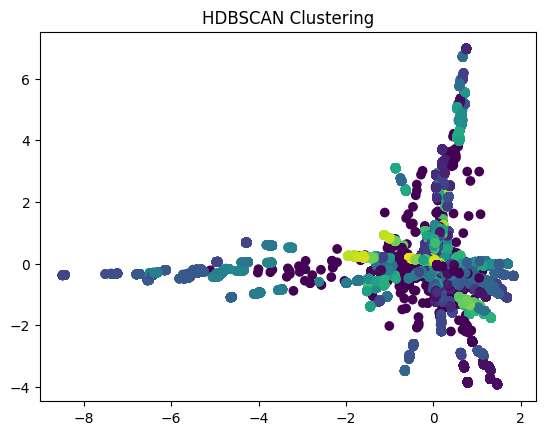

In [30]:
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=clusters, cmap='viridis')
plt.title("HDBSCAN Clustering")
plt.show()

**Prepare Data for GRU**

In [31]:
# Reshape for GRU (samples, timesteps, features)
X_seq = X_reduced.reshape((X_reduced.shape[0], 1, X_reduced.shape[1]))

# Create an array of indices corresponding to the original logs
indices = np.arange(len(logs))

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_seq, labels, indices, test_size=0.2, random_state=42
)

**Build GRU Model**

In [32]:
model = Sequential([
    GRU(64, input_shape=(X_seq.shape[1], X_seq.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,625 (72.75 KB)

 Trainable params: 18,625 (72.75 KB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

In [33]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9879 - loss: 0.0690 - val_accuracy: 0.9874 - val_loss: 0.0464
Epoch 2/5
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9888 - loss: 0.0392 - val_accuracy: 0.9910 - val_loss: 0.0283
Epoch 3/5
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9920 - loss: 0.0291 - val_accuracy: 0.9927 - val_loss: 0.0229
Epoch 4/5
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9934 - loss: 0.0252 - val_accuracy: 0.9940 - val_loss: 0.0213
Epoch 5/5
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9938 - loss: 0.0232 - val_accuracy: 0.9948 - val_loss: 0.0186


**Plot Training Graph**

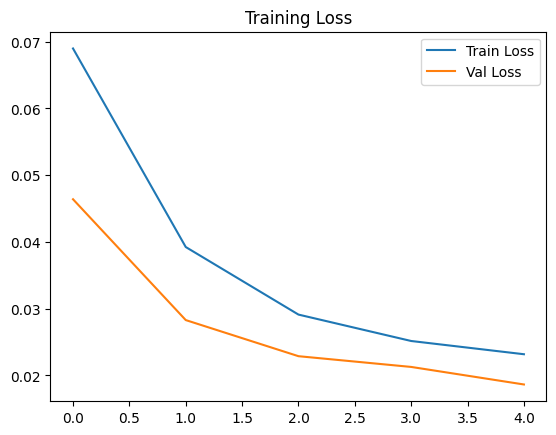

In [34]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training Loss")
plt.show()

**Evaluation**

656/656 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20698
           1       0.89      0.67      0.77       265

    accuracy                           0.99     20963
   macro avg       0.95      0.84      0.88     20963
weighted avg       0.99      0.99      0.99     20963



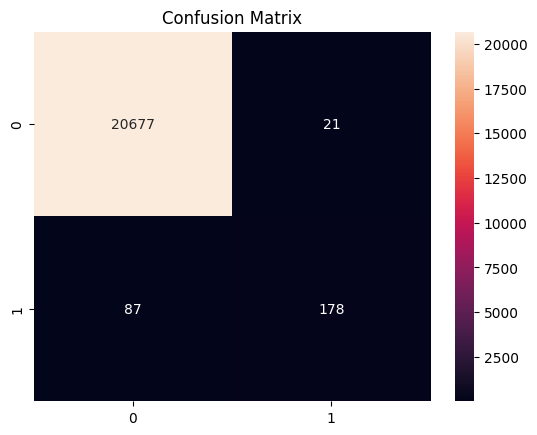

In [35]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [59]:
from sklearn.metrics import accuracy_score

# Accuracy from training history
print(f"Training Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

# Test Accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Training Accuracy: 99.38%
Validation Accuracy: 99.48%
Test Accuracy: 99.48%


/tmp/ipykernel_302/3018183832.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=metrics, palette='viridis')


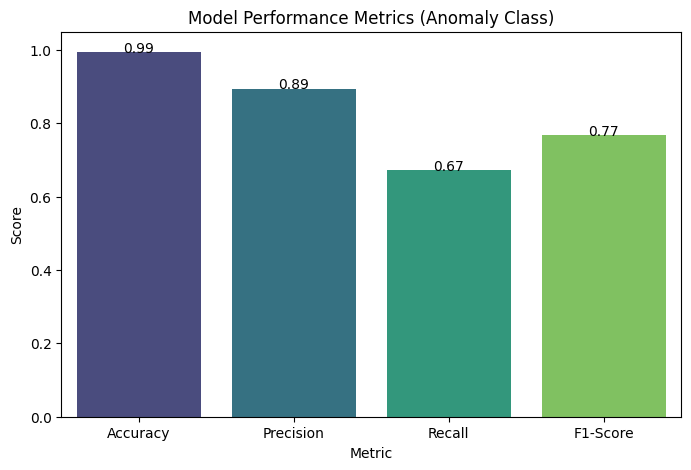

In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Extract metrics for the anomaly class (class 1)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', data=metrics, palette='viridis')
plt.title('Model Performance Metrics (Anomaly Class)')
plt.ylim(0, 1.05) # Set y-axis limit for scores between 0 and 1
plt.ylabel('Score')

for index, row in metrics.iterrows():
    plt.text(row.name, row.Score, f'{row.Score:.2f}', color='black', ha="center")

plt.show()

**Show Anomalies**

In [36]:
df_test = pd.DataFrame({
    "log": logs.iloc[idx_test].values,
    "actual": y_test.flatten(),
    "predicted": y_pred.flatten()
})

anomalies = df_test[df_test['predicted'] == 1]
print(anomalies.head())

                                                   log  actual  predicted
153  10.250.11.100:50010 Served block blk_-35445833...       1          1
206  10.250.10.6:50010 Served block blk_-1608999687...       1          1
353  10.251.111.209:50010 Served block blk_-1608999...       1          1
560  Received block blk_6709103027487563268 of size...       0          1
600  10.251.90.64:50010 Served block blk_-160899968...       1          1


**Online Learning Simulation (Basic)**

In [37]:
# Simulate new logs
new_logs = logs.sample(100)

X_new = vectorizer.transform(new_logs).toarray()
X_new_reduced = ica.transform(X_new)
X_new_seq = X_new_reduced.reshape((X_new_reduced.shape[0], 1, X_new_reduced.shape[1]))

pred_new = model.predict(X_new_seq)

print("New anomalies:", np.sum(pred_new > 0.5))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
New anomalies: 0


**User Authentication (Simulated)**

In [63]:
# --- User Authentication (Simulated) ---
user_id = input("Enter User ID: ")
password = input("Enter Password: ")

# Simulate a simple authentication (replace with actual authentication in a real scenario)
if user_id == "admin" and password == "password123":
    print("\n✅ Authentication successful! Proceeding with anomaly check.")

    # --- Simulate a new log entry for the authenticated user ---
    # For demonstration, we'll create a log that might represent user activity.
    # In a real system, this would come from actual system logs for the user.
    simulated_log_entry = f"User {user_id} logged in successfully from IP 192.168.1.100."
    new_log_series = pd.Series([simulated_log_entry])

    # --- Anomaly Detection for the new log ---
    X_new_single = vectorizer.transform(new_log_series).toarray()
    X_new_single_reduced = ica.transform(X_new_single)
    X_new_single_seq = X_new_single_reduced.reshape((X_new_single_reduced.shape[0], 1, X_new_single_reduced.shape[1]))

    pred_single = model.predict(X_new_single_seq)

    # Determine if it's an anomaly (threshold > 0.5)
    is_anomaly = (pred_single > 0.5).astype(int)[0][0]

    print("\n--- ANOMALY DETECTION DASHBOARD ---")
    print("-----------------------------------")
    print(f"  Simulated Log: '{simulated_log_entry}'")
    print("-----------------------------------")
    if is_anomaly == 1:
        print("  Status: 🚨 ANOMALY DETECTED! 🚨")
        print("  The model predicts this activity is **unusual**.")

        # --- Explainability: Get top TF-IDF words for the anomalous log ---
        feature_names = vectorizer.get_feature_names_out()
        # Get the TF-IDF scores for the single new log entry
        tfidf_scores = X_new_single[0]
        # Get indices of top N features
        top_n_indices = tfidf_scores.argsort()[-5:][::-1] # Top 5 words
        top_n_words = [feature_names[i] for i in top_n_indices if tfidf_scores[i] > 0] # Filter out zero scores
        if top_n_words:
            print(f"  **Top Contributing Words (TF-IDF):** {', '.join(top_n_words)}")
        else:
            print("  No significant unique words found for explainability.")

    else:
        print("  Status: ✅ No anomaly detected.")
        print("  The model predicts this activity is normal.")
    print("-----------------------------------")
    print(f"  Anomaly Prediction Score: {pred_single[0][0]:.4f}")
    print("-----------------------------------")

else:
    print("\n❌ Authentication failed. Please check your credentials.")

Enter User ID: admin
Enter Password: password123

✅ Authentication successful! Proceeding with anomaly check.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

--- ANOMALY DETECTION DASHBOARD ---
-----------------------------------
  Simulated Log: 'User admin logged in successfully from IP 192.168.1.100.'
-----------------------------------
  Status: 🚨 ANOMALY DETECTED! 🚨
  The model predicts this activity is **unusual**.
  **Top Contributing Words (TF-IDF):** 100, 192, user, from
-----------------------------------
  Anomaly Prediction Score: 0.5584
-----------------------------------


**UI**

In [57]:
from IPython.display import display, HTML

html_code = """
<!DOCTYPE html>
<html>
<head>
<style>
body {
    font-family: Arial;
    background-color: teal;
    display: flex;
    justify-content: center;
    align-items: center;
    height: 100vh;
}
.container {
    background: white;
    padding: 30px;
    border-radius: 10px;
    box-shadow: 0px 0px 10px gray;
    width: 300px;
}
input {
    width: 100%;
    padding: 10px;
    margin: 8px 0;
    border-radius: 5px;
    border: 1px solid #ccc;
}
button {
    width: 100%;
    padding: 10px;
    background-color: teal;
    color: white;
    border: none;
    border-radius: 20px;
    cursor: pointer;
}
button:hover {
    background-color: darkcyan;
}
#message {
    margin-top: 10px;
    font-weight: bold;
}
</style>

<script>
function validateLogin() {
    var username = document.getElementById("username").value;
    var password = document.getElementById("password").value;

    // 👇 Your login credentials
    var validUser = "admin";
    var validPass = "1234";

    if (username === validUser && password === validPass) {
        document.getElementById("message").innerHTML = "✅ Login Successful!";
        document.getElementById("message").style.color = "green";
    } else {
        document.getElementById("message").innerHTML = "❌ Invalid Username or Password";
        document.getElementById("message").style.color = "red";
    }
}

// Show password toggle
function togglePassword() {
    var x = document.getElementById("password");
    if (x.type === "password") {
        x.type = "text";
    } else {
        x.type = "password";
    }
}
</script>

</head>

<body>

<div class="container">
    <h2>Login</h2>

    <input type="text" id="username" placeholder="Username or Email">
    <input type="password" id="password" placeholder="Password">

    <label>
        <input type="checkbox" onclick="togglePassword()"> Show Password
    </label><br><br>

    <label>
        <input type="checkbox"> Keep me logged in
    </label><br><br>

    <button onclick="validateLogin()">Log in</button>

    <p id="message"></p>
</div>

</body>
</html>
"""

display(HTML(html_code))